# ETL Pipeline - Second Delivery
**Vacunación Ecuador** - **Apache Airflow** - **Great Expectations**

## Flujo del DAG


Este pipeline busca consolidar tres fuentes en un único Data Warehouse analítico para responder preguntas concretas sobre equidad, eficacia y progreso de la campaña de vacunación implementada en Ecuador durante el año 2021.

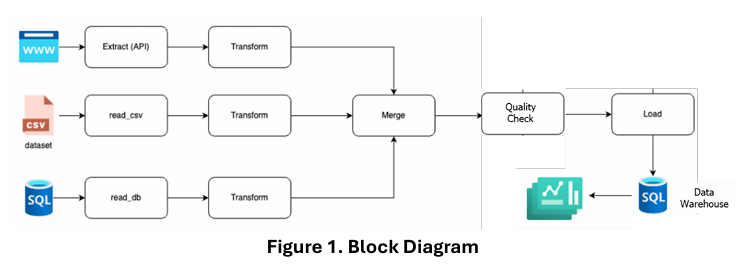

## -Montar drive y definir rutas

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

ruta_directorio_drive   = "/content/drive/Shared drives/ETL_second_delivery/"
ruta_dwh_first_delivery = ruta_directorio_drive + "vacunacion_ecuador_dw_gold_layer.db"
ruta_dwh_second_delivery = ruta_directorio_drive + "vacunacion_ecuador_dw_second_delivery.db"

Mounted at /content/drive


##- Instalar AirFlow

In [ ]:
import os
import sys

python_version = f"{sys.version_info.major}.{sys.version_info.minor}"
constraint_url = f"https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-{python_version}.txt"
!pip install 'apache-airflow==2.11.2' 'great-expectations>=1.0.0' \
    --constraint {constraint_url} > /dev/null 2>&1

os.environ["AIRFLOW_HOME"] = "/content/airflow"
os.environ["AIRFLOW__CORE__LOAD_EXAMPLES"] = "False"
os.environ["AIRFLOW__WEBSERVER__WEB_SERVER_PORT"] = "8081"

!airflow db migrate > /dev/null 2>&1
!mkdir -p /content/airflow/dags

print("AirFlow instalado y configurado")

AirFlow instalado y configurado


##- Autenticacion BigQuery
Se autentica antes de iniciar Airflow para que los tasks hereden las credenciales ADC (application default credentials)

In [ ]:
from google.colab import auth, userdata
auth.authenticate_user()

#exportar project_id para que las tareas del DAG lo lean como variable de entorno
os.environ["GCP_PROJECT_ID"] = userdata.get("project_gcp")
print("BigQuery autenticado")

BigQuery autenticado


##- DAG -> pipeline ETL vacunacion Ecuador

-Analisis visual de la informacion disponible

-Esquema dwh primera entrega para comprender la estructura de la BD:
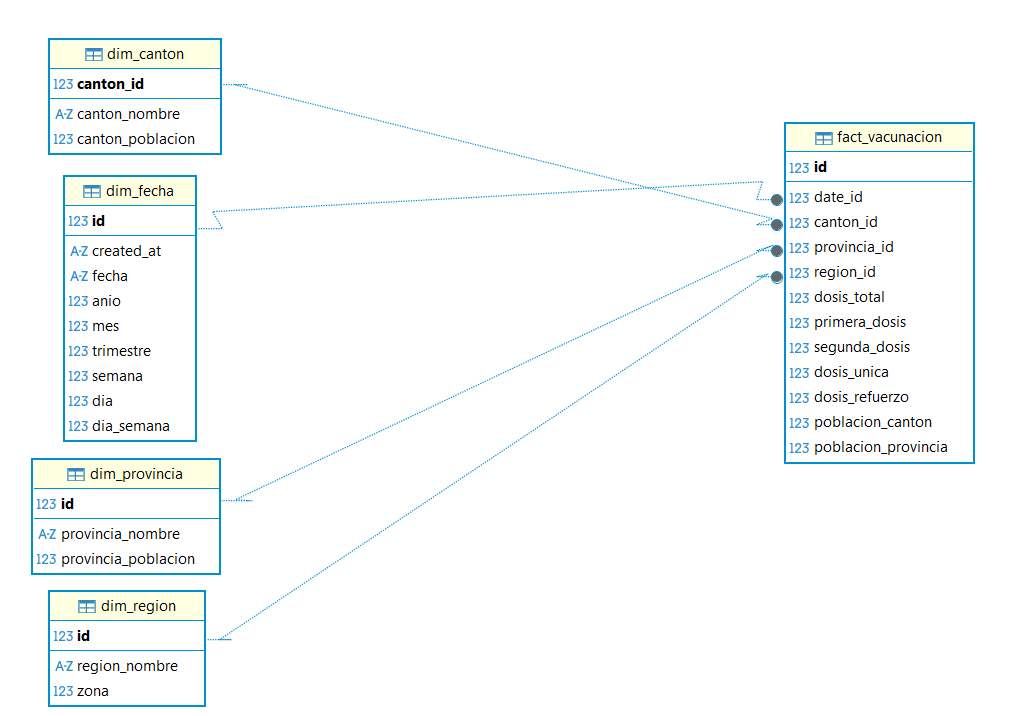

Decesos ecuador:

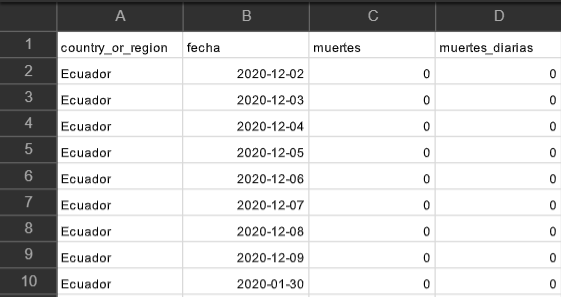

.
.
.

-Indicador UHC

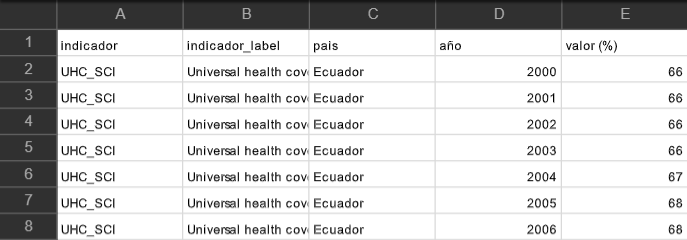

.
.
.

In [ ]:
%%writefile /content/airflow/dags/etl_vacunacion_ecuador.py
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime

default_args = {
    "owner": "data_engineer",
    "depends_on_past": False,
    "retries": 3,
}

with DAG(
    "etl_vacunacion_ecuador",
    default_args      = default_args,
    schedule_interval = "@daily",
    start_date        = datetime(2018, 1, 1),
    catchup           = False,
) as dag:


    # TASK 1 -> Extraccion desde BD SQL (primera entrega)

    def extract_db():
        import sqlite3
        import pandas as pd

        ruta_dwh_first_delivery = "/content/drive/Shared drives/proyecto_ETL/vacunacion_ecuador_dw_gold_layer.db"

        conn = sqlite3.connect(ruta_dwh_first_delivery)
        pd.read_sql("SELECT * FROM fact_vacunacion", conn).to_csv("/content/tmp_fact.csv",      index=False)
        pd.read_sql("SELECT * FROM dim_fecha",       conn).to_csv("/content/tmp_fecha.csv",     index=False)
        pd.read_sql("SELECT * FROM dim_canton",      conn).to_csv("/content/tmp_canton.csv",    index=False)
        pd.read_sql("SELECT * FROM dim_provincia",   conn).to_csv("/content/tmp_provincia.csv", index=False)
        pd.read_sql("SELECT * FROM dim_region",      conn).to_csv("/content/tmp_region.csv",    index=False)
        conn.close()
        print("Extracion de BD finalizada")


    # TASK 2 -> Extraccion desde BQ (muertes COVID-19 Ecuador)

    def extract_bigquery():
        import os
        import pandas as pd
        from google.cloud import bigquery

        client = bigquery.Client(project=os.environ.get("GCP_PROJECT_ID"))

        query = '''
            SELECT *
            FROM `bigquery-public-data.covid19_jhu_csse.deaths`
            WHERE country_or_region = "Ecuador"
        '''

        df = client.query(query).to_dataframe()
        df.to_csv("/content/tmp_covid_raw.csv", index=False)
        print(f"Extraccion de BigQuery completada - {df.shape[0]} filas, {df.shape[1]} columnas")


    # TASK 3 -> Extraccion desde API (World Bank UHC Index)

    def extract_api():
        import requests
        import pandas as pd
        from io import StringIO

        url     = "https://data360files.worldbank.org/data360-data/data/WB_UHC/UHC_SCI.csv"
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

        response = requests.get(url, headers = headers, timeout=30)
        response.raise_for_status()

        df = pd.read_csv(StringIO(response.text))
        df.to_csv("/content/tmp_uhc_raw.csv", index=False)
        print(f"Extract API OK — {df.shape[0]} filas descargadas")


    # TASK 4 -> Transformaciones y Merge

    def transform():
        import pandas as pd

        #Fuente 1: primera entrega
        df_fact       = pd.read_csv("/content/tmp_fact.csv")
        df_dim_fecha  = pd.read_csv("/content/tmp_fecha.csv")
        df_dim_canton = pd.read_csv("/content/tmp_canton.csv")
        df_dim_prov   = pd.read_csv("/content/tmp_provincia.csv")
        df_dim_reg    = pd.read_csv("/content/tmp_region.csv")

        #Limpiar dim_fecha
        df_dim_fecha["fecha"] = pd.to_datetime(df_dim_fecha["fecha"], errors="coerce")  #convierte a datetime

        for col in ["anio","mes","trimestre","semana","dia","dia_semana"]:
            df_dim_fecha[col] = df_dim_fecha[col].astype(int)  #convierte en entero

        duplicados_identicos = df_dim_fecha[df_dim_fecha.duplicated(keep=False)] #ver los duplicados identicos para decidir si eliminarlos es correcto
        print("Duplicados identicos:")
        print(duplicados_identicos)
        df_dim_fecha = df_dim_fecha.drop_duplicates()

        duplicados_por_id = df_dim_fecha[df_dim_fecha.duplicated(subset="id", keep=False)] #ver duplicados por id para decidir si eliminarlos es correcto
        print("\nDuplicados por ID:")                                                      #(asegurar integridad referencial por id)
        print(duplicados_por_id.sort_values("id"))
        if not duplicados_por_id.empty:
          raise ValueError("Hay IDs duplicados. Revisar antes de continuar.")
        #df_dim_fecha = df_dim_fecha.drop_duplicates(subset="id")


        #Limpiar dim_canton
        df_dim_canton["canton_nombre"]    = df_dim_canton["canton_nombre"].str.strip().str.title()  #eliminar espacios y poner primera en mayuscula
        df_dim_canton["canton_poblacion"] = pd.to_numeric(df_dim_canton["canton_poblacion"], errors="coerce").fillna(0).astype(int)
        df_dim_canton = df_dim_canton.drop_duplicates()

        duplicados_por_id = df_dim_canton[df_dim_canton.duplicated(subset="canton_id", keep=False)]
        print("Duplicados por canton_id:")
        print(duplicados_por_id)
        if not duplicados_por_id.empty:
            raise ValueError("Hay canton_id duplicados. Revisar.")
        #df_dim_canton = df_dim_canton.drop_duplicates(subset="canton_id")


        #Limpiar dim_provincia
        df_dim_prov["provincia_nombre"]    = df_dim_prov["provincia_nombre"].str.strip().str.title()
        df_dim_prov["provincia_poblacion"] = pd.to_numeric(df_dim_prov["provincia_poblacion"], errors="coerce").fillna(0).astype(int) #convertir a entero
        df_dim_canton = df_dim_canton.drop_duplicates() #eliminar duplicados exactos

        duplicados_por_id = df_dim_prov[df_dim_prov.duplicated(subset="id", keep=False)]
        print("Duplicados por id:")
        print(duplicados_por_id)
        if not duplicados_por_id.empty:
            raise ValueError("Hay ids duplicados. Revisar.")
        #df_dim_prov = df_dim_prov.drop_duplicates(subset="id")


        #Limpiar dim_region
        df_dim_reg["region_nombre"] = df_dim_reg["region_nombre"].str.strip().str.title()
        df_dim_reg["zona"] = pd.to_numeric(df_dim_reg["zona"], errors="coerce").fillna(0).astype(int)
        df_dim_reg = df_dim_reg.drop_duplicates()

        duplicados_por_id = df_dim_reg[df_dim_reg.duplicated(subset = "id", keep = False)]
        print("Duplicados por id:")
        print(duplicados_por_id)
        if not duplicados_por_id.empty:
          raise ValueError("Hay ids duplicados. Revisar.")
        #df_dim_reg = df_dim_reg.drop_duplicates(subset="id")


        #Limpiar fact_vacunacion
        for col in ["dosis_total","primera_dosis","segunda_dosis","dosis_unica",
                    "dosis_refuerzo","poblacion_canton","poblacion_provincia"]:
            df_fact[col] = pd.to_numeric(df_fact[col], errors="coerce").fillna(0).astype(int)
        df_fact = df_fact.drop_duplicates()

        duplicados_por_id = df_fact[df_fact.duplicated(subset = "id", keep = False)]
        print("Duplicados por id:")
        print(duplicados_por_id)
        if not duplicados_por_id.empty:
          raise ValueError("Hay ids duplicados. Revisar.")


        #Fuente 2: COVID deaths (wide -> long)
        df_covid_raw = pd.read_csv("/content/tmp_covid_raw.csv")

        meta_cols = ["province_or_state","country_or_region","latitude","longitude","location_geom"]
        date_cols = [c for c in df_covid_raw.columns if c not in meta_cols]

        df_covid = df_covid_raw[["country_or_region"] + date_cols].melt(
            id_vars=["country_or_region"],
            var_name="fecha_raw",
            value_name="muertes_acumuladas")

        def parse_covid_date(col):
            try:
                parts = col.strip("_").split("_")  #elimina los _ presentes en la fecha y divide la fecha usando el _
                return pd.to_datetime(f"20{parts[2]}-{parts[0].zfill(2)}-{parts[1].zfill(2)}")  #cambia el formayo a año/mes/dia
            except Exception:
                return pd.NaT  #si falla devuelve not a time

        df_covid["fecha"] = df_covid["fecha_raw"].apply(parse_covid_date)
        df_covid["muertes_acumuladas"] = pd.to_numeric(df_covid["muertes_acumuladas"], errors="coerce").fillna(0).astype(int)
        df_covid = df_covid.dropna(subset=["fecha"]).sort_values("fecha").reset_index(drop=True)  #si hay nat los elimina
        df_covid["muertes_diarias"] = df_covid["muertes_acumuladas"].diff().clip(lower=0).fillna(0).astype(int)  #calcula las muertes diarias (calcula la diferencia entre cada fila y la anterior)
        df_covid["anio"] = df_covid["fecha"].dt.year
        df_covid["mes"] = df_covid["fecha"].dt.month
        df_covid["fecha"] = df_covid["fecha"].dt.strftime("%Y-%m-%d") #transforma de datetime a string
        df_covid = df_covid[["fecha","anio","mes","muertes_acumuladas","muertes_diarias"]]

        #Fuente 3: UHC API
        df_uhc_raw = pd.read_csv("/content/tmp_uhc_raw.csv")

        df_uhc = df_uhc_raw[
            (df_uhc_raw["REF_AREA_LABEL"] == "Ecuador") &   #solo selecciona los registros de ecuador
            (df_uhc_raw["INDEX_COMP_LABEL"] == "Full index")  # y los registros con las metricas de full indix ya que hay sub-indicadores
        ][["TIME_PERIOD","OBS_VALUE"]].copy()  #selecciona solo la columna de la fecha y el valor del indicador en esa fecha
        df_uhc.columns = ["anio","uhc_score"] #renombrar columnas
        df_uhc["anio"] = df_uhc["anio"].astype(int)
        df_uhc["uhc_score"] = pd.to_numeric(df_uhc["uhc_score"], errors="coerce")
        df_uhc = df_uhc.dropna().drop_duplicates(subset="anio").sort_values("anio", ascending=False).reset_index(drop=True)

        #Merge por año
        df_fact_fecha = df_fact.merge(
            df_dim_fecha[["id","anio","mes"]],
            left_on="date_id", right_on="id", how="left") # une por medio del id

        #df_vac_anual = df_fact_fecha.groupby("anio").agg(
          #  dosis_total    = ("dosis_total",    "sum"),
           # primera_dosis  = ("primera_dosis",  "sum"),
            #segunda_dosis  = ("segunda_dosis",  "sum"),
            #dosis_unica    = ("dosis_unica",    "sum"),
            #dosis_refuerzo = ("dosis_refuerzo", "sum")).reset_index()  #agrupa por año y suma los tipos de dosis
        dosis_cols = [
          "dosis_total",
          "primera_dosis",
          "segunda_dosis",
          "dosis_unica",
          "dosis_refuerzo"]
        _fact_max    = df_fact_fecha.groupby(["anio","canton_id"])[dosis_cols].max().reset_index()
        df_vac_anual = _fact_max.groupby("anio")[dosis_cols].sum().reset_index()

        df_covid_anual = df_covid.groupby("anio").agg(
            total_muertes_covid = ("muertes_diarias",    "sum"),
            max_muertes_acum    = ("muertes_acumuladas", "max")).reset_index()  #agrupa por anio y calcula el total de muertes

        df_merged = df_vac_anual \
            .merge(df_covid_anual, on="anio", how="left") \
            .merge(df_uhc,         on="anio", how="left") \
            .sort_values("anio").reset_index(drop=True)  #une todos los datos

        #df_fact["uhc_anio"] = 2021 ############

        #Guardar resultados transformados
        df_dim_fecha["fecha"] = df_dim_fecha["fecha"].dt.strftime("%Y-%m-%d")
        df_fact.to_csv("/content/tf_fact.csv",            index=False)
        df_dim_fecha.to_csv("/content/tf_fecha.csv",      index=False)
        df_dim_canton.to_csv("/content/tf_canton.csv",    index=False)
        df_dim_prov.to_csv("/content/tf_provincia.csv",   index=False)
        df_dim_reg.to_csv("/content/tf_region.csv",       index=False)
        df_covid.to_csv("/content/tf_covid.csv",          index=False)
        df_uhc.to_csv("/content/tf_uhc.csv",              index=False)
        df_merged.to_csv("/content/tf_merged.csv",        index=False)

        ruta = "/content/drive/Shared drives/ETL_second_delivery/"
        df_fact.to_csv(ruta + "tf_fact.csv", index=False)
        df_dim_fecha.to_csv(ruta + "tf_fecha.csv", index=False)
        df_dim_canton.to_csv(ruta + "tf_canton.csv", index=False)
        df_dim_prov.to_csv(ruta + "tf_provincia.csv", index=False)
        df_dim_reg.to_csv(ruta + "tf_region.csv", index=False)
        df_covid.to_csv(ruta + "tf_covid.csv", index=False)
        df_uhc.to_csv(ruta + "tf_uhc.csv", index=False)
        df_merged.to_csv(ruta + "tf_merged.csv", index=False)

        print(f"Transformacion realizada — dimensiones merged: {df_merged.shape}")

        #guardar en drive para hacer EDA en otro notebook
        ruta_directorio_drive   = "/content/drive/Shared drives/ETL_second_delivery/"
        df_merged.to_csv(ruta_directorio_drive + "tf_merged.csv",     index=False)
        df_covid.to_csv(ruta_directorio_drive  + "tf_covid.csv",      index=False)
        df_uhc.to_csv(ruta_directorio_drive    + "tf_uhc.csv",        index=False)
        df_fact.to_csv(ruta_directorio_drive   + "tf_fact.csv",       index=False)



    #TASK 5 — Quality Checks (Great Expectations)

    def quality_checks():

      import great_expectations as gx
      import great_expectations.expectations as gxe
      import pandas as pd
      import warnings
      warnings.filterwarnings("ignore")

      print("Iniciando quality checks con Great Expectations")

      context = gx.get_context()
      errores = []

      def validar(nombre_tabla, df, reglas):
          batch = context.data_sources.pandas_default.read_dataframe(df)
          print(f"\n── {nombre_tabla} ──")
          for regla in reglas:
              resultado = batch.validate(regla)
              tipo      = regla.expectation_type
              columna   = getattr(regla, "column", "tabla")
              if resultado.success:
                  print(f"  ok {columna} , {tipo}")
              else:
                  detalle = resultado.result.get("partial_unexpected_list", "sin detalle")
                  msg     = f"fallo [{nombre_tabla}] {columna} , {tipo} -> valores inesperados: {detalle}"
                  print(f"  {msg}")
                  errores.append(msg)

      #fact_vacunacion
      validar("fact_vacunacion", pd.read_csv("/content/tf_fact.csv"), [
          gxe.ExpectTableRowCountToBeBetween(min_value=1),
          gxe.ExpectColumnValuesToNotBeNull(column="date_id"),
          gxe.ExpectColumnValuesToNotBeNull(column="canton_id"),
          gxe.ExpectColumnValuesToNotBeNull(column="provincia_id"),
          gxe.ExpectColumnValuesToBeBetween(column="dosis_total",    min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="primera_dosis",  min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="segunda_dosis",  min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="dosis_unica",    min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="dosis_refuerzo", min_value=0),
      ])

      #dim_canton
      validar("dim_canton", pd.read_csv("/content/tf_canton.csv"), [
          gxe.ExpectTableRowCountToBeBetween(min_value=1),
          gxe.ExpectColumnValuesToNotBeNull(column="canton_id"),
          gxe.ExpectColumnValuesToBeUnique(column="canton_id"),
          gxe.ExpectColumnValuesToNotBeNull(column="canton_nombre"),
          gxe.ExpectColumnValuesToBeBetween(column="canton_poblacion", min_value=0),
      ])

      #dim_fecha
      validar("dim_fecha", pd.read_csv("/content/tf_fecha.csv"), [
          gxe.ExpectTableRowCountToBeBetween(min_value=1),
          gxe.ExpectColumnValuesToNotBeNull(column="id"),
          gxe.ExpectColumnValuesToBeUnique(column="id"),
          gxe.ExpectColumnValuesToNotBeNull(column="fecha"),
          gxe.ExpectColumnValuesToBeBetween(column="mes", min_value=1,  max_value=12),
          gxe.ExpectColumnValuesToBeBetween(column="dia", min_value=1,  max_value=31),
      ])

      #covid_deaths_ecuador
      validar("covid_deaths", pd.read_csv("/content/tf_covid.csv"), [
          gxe.ExpectTableRowCountToBeBetween(min_value=1),
          gxe.ExpectColumnValuesToNotBeNull(column="fecha"),
          gxe.ExpectColumnValuesToBeBetween(column="muertes_acumuladas", min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="muertes_diarias",    min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="mes", min_value=1, max_value=12),
      ])

      #uhc_index_ecuador
      validar("uhc_index", pd.read_csv("/content/tf_uhc.csv"), [
          gxe.ExpectTableRowCountToBeBetween(min_value=1),
          gxe.ExpectColumnValuesToNotBeNull(column="anio"),
          gxe.ExpectColumnValuesToBeUnique(column="anio"),
          gxe.ExpectColumnValuesToNotBeNull(column="uhc_score"),
          gxe.ExpectColumnValuesToBeBetween(column="uhc_score", min_value=0, max_value=100),
      ])

      #fact_vacunacion_enriquecida
      validar("fact_merged", pd.read_csv("/content/tf_merged.csv"), [
          gxe.ExpectTableRowCountToBeBetween(min_value=1),
          gxe.ExpectColumnValuesToNotBeNull(column="anio"),
          gxe.ExpectColumnValuesToBeUnique(column="anio"),
          gxe.ExpectColumnValuesToBeBetween(column="dosis_total",   min_value=0),
          gxe.ExpectColumnValuesToBeBetween(column="primera_dosis", min_value=0),
      ])

      #Resultado
      if errores:
          raise Exception(
              f"Quality checks fallidos — {len(errores)} error(es):\n" +
              "\n".join(errores)
          )

      print("\n Quality Checks completados - todas las expectativas se cumplen")



    #TASK 6 - carga al DWH (star schema con SQLite)

    def load():
      import sqlite3
      import pandas as pd

      ruta_dwh_second_delivery = "/content/drive/Shared drives/ETL_second_delivery/vacunacion_ecuador_dw_second_delivery.db"

      conn = sqlite3.connect(ruta_dwh_second_delivery)
      cur  = conn.cursor()
      cur.execute("PRAGMA foreign_keys = ON;")  #asegurar integridad referencial por defecto viene deshabilitado

      cur.executescript("""
          DROP TABLE IF EXISTS fact_vacunacion;
          DROP TABLE IF EXISTS fact_decesos;
          DROP TABLE IF EXISTS dim_indice_uhc;
          DROP TABLE IF EXISTS dim_fecha;
          DROP TABLE IF EXISTS dim_canton;
          DROP TABLE IF EXISTS dim_provincia;
          DROP TABLE IF EXISTS dim_region;
      """)
      conn.commit()

      cur.executescript("""

            --dimension fecha (la comparten ambas tablas de hechos)
            CREATE TABLE dim_fecha (
                id          INTEGER PRIMARY KEY,
                created_at  TEXT,
                fecha       TEXT    NOT NULL UNIQUE,
                anio        INTEGER NOT NULL,
                mes         INTEGER NOT NULL,
                trimestre   INTEGER NOT NULL,
                semana      INTEGER NOT NULL,
                dia         INTEGER NOT NULL,
                dia_semana  INTEGER NOT NULL
            );

            --dimension canton
            CREATE TABLE dim_canton (
                canton_id        INTEGER PRIMARY KEY,
                canton_nombre    TEXT    NOT NULL,
                canton_poblacion INTEGER
            );

            --dimension provincia
            CREATE TABLE dim_provincia (
                id                   INTEGER PRIMARY KEY,
                provincia_nombre     TEXT    NOT NULL UNIQUE,
                provincia_poblacion  INTEGER
            );

            --dimensión region
            CREATE TABLE dim_region (
                id            INTEGER PRIMARY KEY,
                region_nombre TEXT    NOT NULL UNIQUE,
                zona          INTEGER
            );

            --dimensión indice UHC (anual)
            CREATE TABLE dim_indice_uhc (
                anio       INTEGER PRIMARY KEY,
                uhc_score  REAL    NOT NULL
            );

            --tabla de hechos 1: vacunacion
            --se relaciona con fact_decesos a traves de dim_fecha
            --el fact_vacunacion.date_id = fact_decesos.date_id para los registros del mimso dia
            CREATE TABLE fact_vacunacion (
                id                  INTEGER PRIMARY KEY,
                date_id             INTEGER NOT NULL REFERENCES dim_fecha(id),
                canton_id           INTEGER NOT NULL REFERENCES dim_canton(canton_id),
                provincia_id        INTEGER NOT NULL REFERENCES dim_provincia(id),
                region_id           INTEGER NOT NULL REFERENCES dim_region(id),
                dosis_total         INTEGER,
                primera_dosis       INTEGER,
                segunda_dosis       INTEGER,
                dosis_unica         INTEGER,
                dosis_refuerzo      INTEGER,
                poblacion_canton    INTEGER,
                poblacion_provincia INTEGER
            );

            --tabla de hechos 2: decesos COVID
            --comparte dim_fecha con fact_vacunacion.
            --JOIN entre hechos: fact_vacunacion.date_id = fact_decesos.date_id para obtener los registros de la misma fecha
            CREATE TABLE fact_decesos (
                id                  INTEGER PRIMARY KEY AUTOINCREMENT,
                date_id             INTEGER NOT NULL UNIQUE REFERENCES dim_fecha(id),
                muertes_acumuladas  INTEGER NOT NULL,
                muertes_diarias     INTEGER NOT NULL
            );

        """)
      conn.commit()

      #carga en orden
      df_fecha = pd.read_csv("/content/tf_fecha.csv")
      df_fecha.to_sql("dim_fecha", conn, if_exists="append", index=False)
      pd.read_csv("/content/tf_canton.csv").to_sql("dim_canton", conn, if_exists="append", index=False)
      pd.read_csv("/content/tf_provincia.csv").to_sql("dim_provincia", conn, if_exists="append", index=False)
      pd.read_csv("/content/tf_region.csv").to_sql("dim_region", conn, if_exists="append", index=False)
      pd.read_csv("/content/tf_uhc.csv").to_sql("dim_indice_uhc", conn, if_exists="append", index=False)

      # fact_decesos: solo las fechas de que existan en dim_fecha
      df_covid = pd.read_csv("/content/tf_covid.csv")
      fecha_a_id = df_fecha.set_index("fecha")["id"].to_dict() #crea un diccionario en el que la clave es la fecha y su valor es el id
      df_decesos = df_covid[df_covid["fecha"].isin(fecha_a_id)].copy() #selecciona solo las dechas que esten en dim_fecha
      df_decesos["date_id"] = df_decesos["fecha"].map(fecha_a_id) #mapea la fecha al id devolviendo el valor (id) de esa fecha
      df_decesos = df_decesos[["date_id", "muertes_acumuladas","muertes_diarias"]]
      df_decesos = df_decesos.drop_duplicates(subset="date_id")
      df_decesos.to_sql("fact_decesos", conn, if_exists="append", index=False)

      df_fact = pd.read_csv("/content/tf_fact.csv")
      df_fact.to_sql("fact_vacunacion", conn, if_exists="append", index=False)


      conn.commit()

      # Verificar rowcounts
      tablas = pd.read_sql('SELECT name FROM sqlite_master WHERE type="table"', conn)
      for t in tablas["name"]:
          n = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn).iloc[0, 0]
          print(f"  {t:<30} {n:>8,} filas")

      conn.close()
      print("Load OK — DWH guardado en:", ruta_dwh_second_delivery)


    # Definicion de tareas y logica de ejecucion

    t_extract_db  = PythonOperator(task_id="extract_db",       python_callable=extract_db)
    t_extract_bq  = PythonOperator(task_id="extract_bigquery", python_callable=extract_bigquery)
    t_extract_api = PythonOperator(task_id="extract_api",      python_callable=extract_api)
    t_transform   = PythonOperator(task_id="transform",        python_callable=transform)
    t_quality     = PythonOperator(task_id="quality_checks",   python_callable=quality_checks)
    t_load        = PythonOperator(task_id="load",             python_callable=load)

    #las 3 extracciones van primero, luego transform -> quality -> load
    [t_extract_db, t_extract_bq, t_extract_api] >> t_transform >> t_quality >> t_load

Writing /content/airflow/dags/etl_vacunacion_ecuador.py


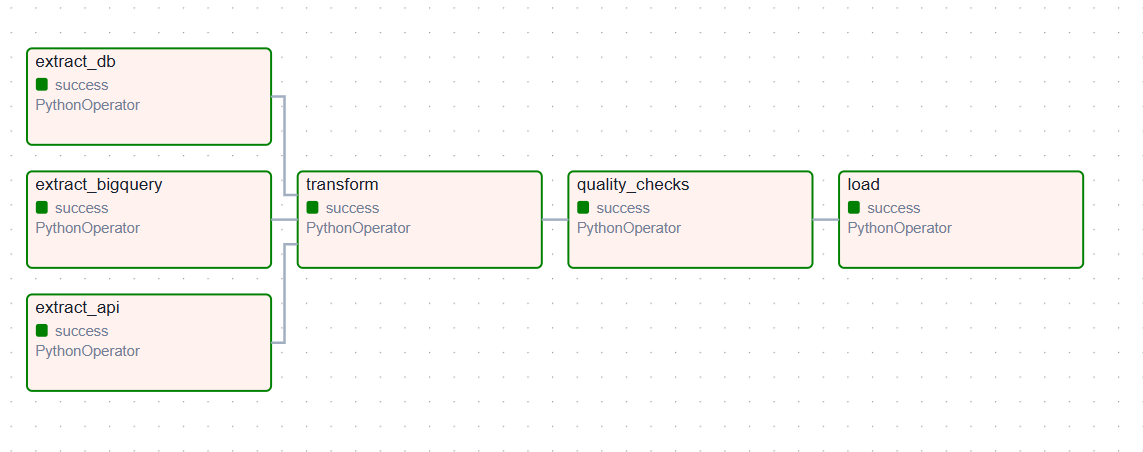

##- Crear usuario administrador

In [ ]:
!airflow users create \
    --username admin \
    --password admin \
    --firstname Admin \
    --lastname User \
    --role Admin \
    --email admin@example.com

[2026-04-15T18:45:57.177+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.schemas
[2026-04-15T18:45:57.179+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.tables
[2026-04-15T18:45:57.180+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.types
[2026-04-15T18:45:57.180+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.constraints
[2026-04-15T18:45:57.181+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.defaults
[2026-04-15T18:45:57.181+0000] {plugins.py:37} INFO - setup plugin alembic.autogenerate.comments
/usr/local/lib/python3.12/dist-packages/flask_limiter/extension.py:324 UserWarning: Using the in-memory storage for tracking rate limits as no storage was explicitly specified. This is not recommended for production use. See: https://flask-limiter.readthedocs.io#configuring-a-storage-backend for documentation about configuring the storage backend.
[2026-04-15T18:45:57.860+0000] {override.py:1528} INFO - Inserted Role:

##- Iniciar AirFlow + tunel publico (Cloudflare)

In [ ]:
import time, re, os, subprocess

print("Iniciando Airflow...")

get_ipython().system_raw("airflow webserver -p 8081 > /content/web.log 2>&1 &")
get_ipython().system_raw("airflow scheduler > /content/scheduler.log 2>&1 &")

# Esperar hasta que el webserver responda (máx 120 seg)
import urllib.request
print("Esperando que Airflow arranque", end="")
for _ in range(24):
    time.sleep(5)
    try:
        urllib.request.urlopen("http://localhost:8081/health", timeout=3)
        print("    listo")
        break
    except Exception:
        print(".", end="", flush=True)
else:
    print("\nAirflow tardó más de lo esperado — revisar /content/web.log")

# Crear túnel solo cuando el webserver ya responde
os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared")
os.system("chmod +x cloudflared")

get_ipython().system_raw("./cloudflared tunnel --url http://localhost:8081 > /content/tunnel.log 2>&1 &")

time.sleep(8)  # darle tiempo al túnel de registrarse

with open("/content/tunnel.log") as f:
    log = f.read()

url = re.findall(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", log)

if url:
    print("Airflow UI:", url[0])
    print("Usuario: admin  |  Contraseña: admin")
else:
    print("No se encontró URL — espera 10 segundos y corre esta celda de nuevo")
    print(log[-500:])  # últimas líneas del log para diagnosticar

Iniciando Airflow...
Esperando que Airflow arranque.....    listo
Airflow UI: https://metadata-bare-difficulty-fitness.trycloudflare.com
Usuario: admin  |  Contraseña: admin


# ***-Diagrama DWH final***

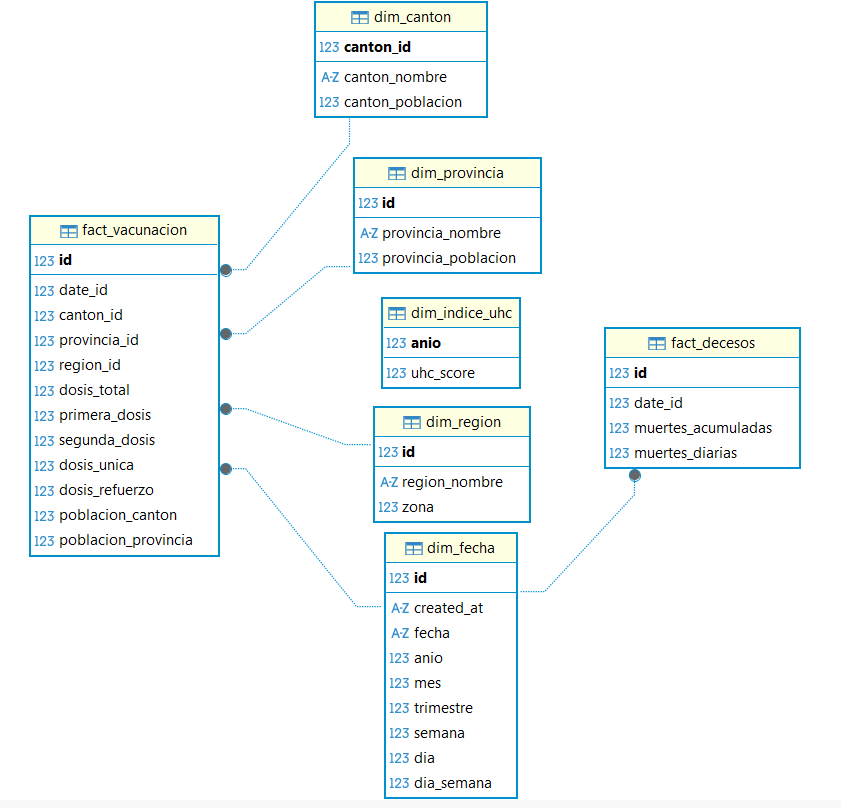